In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver

In [4]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
llm = ChatOpenAI()

def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [12]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

# add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

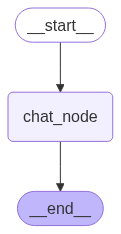

In [10]:
chatbot

In [11]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content


'The capital of India is New Delhi.'

In [17]:
thread_id = '1'

while True:

    user_message = input('Type here: ')
    print('User: ', user_message)

    if user_message.strip().lower() in ['exit', 'bye', 'quit']:
        break

    config = {'configurable': {'thread_id': thread_id}}

    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print('AI: ', response['messages'][-1].content)

User:  Hi
AI:  Hello! How can I help you today?
User:  My name is Rohan
AI:  Nice to meet you, Rohan! How can I assist you today?
User:  whats my name?
AI:  Your name is Rohan.
User:  good bye mean?
AI:  "Goodbye" is a polite way to bid farewell or say goodbye to someone.
User:  bye


: 

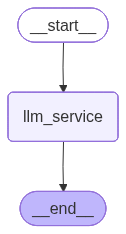

In [12]:
from dotenv import load_dotenv
load_dotenv()

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages

class VoiceState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

llm = ChatOpenAI()
def llm_service(state: VoiceState):
    # take user query from state
    messages = state['messages']
    # send to llm
    response = llm.invoke(messages)
    # response store state
    return {'messages': [response]}

# Memory
checkpointer = MemorySaver()
# Graph Foundation
graph = StateGraph(VoiceState)

graph.add_node('llm_service', llm_service)

graph.add_edge(START, 'llm_service')
graph.add_edge('llm_service', END)

workflow = graph.compile()

workflow

In [13]:
chatbot = graph.compile(checkpointer=checkpointer)

In [14]:
thread_id = '1'

while True:

    user_message = input('Type here: ')
    print('User: ', user_message)

    if user_message.strip().lower() in ['exit', 'bye', 'quit']:
        break

    config = {'configurable': {'thread_id': thread_id}}

    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print('AI: ', response['messages'][-1].content)

User:  Hello I'm Rohan
AI:  Hello Rohan! How can I assist you today?
User:  What's my Name?
AI:  Your name is Rohan.
User:  bye
